# Unified Cyber-Defense Optimal Control → QUBO → CP-SAT / SA / Variational QAOA / IBM Quantum

**Corrected, paper-worthy pipeline.**

Control-theoretic cyber-defense optimal control → exact QUBO reduction → solved by the *same* QUBO instance across:
- **CP-SAT** (exact/strong classical baseline, OR-Tools)
- **Simulated Annealing** (dimod)
- **Brute force** (exact optimum, small instances only — used for approximation ratios)
- **Variational QAOA** with COBYLA angle optimization (local Aer simulation)
- **IBM Quantum QAOA** using transferred optimized angles (feasibility / scale demonstration)

### What was fixed relative to a naive QAOA demo
1. **QAOA angles are now optimized** (COBYLA over γ, β), not hard-coded. Fixed angles do not constitute QAOA.
2. **Consistent objective accounting.** The circuit is built on a *pruned* Ising graph (top-`max_edges` couplings to control depth). We now report the energy on **both** the pruned objective the circuit actually targets **and** the full QUBO, plus the **fraction of coupling weight retained**, so the comparison is transparent.
3. **Approximation ratio / gap-to-best-known** is reported, not just raw energy.
4. **Large instances are explicitly framed as a feasibility/scale demonstration**, using angles transferred from small optimized instances (parameter transferability, Galda et al. 2021).

### Recommended quantum experiments

| Nodes | Horizon | Qubits = nH |
|---:|---:|---:|
| 8  | 8 | 64  |
| 16 | 8 | 128 |
| 19 | 8 | 152 |

For a 156-qubit IBM device, the largest recommended instance is n=19, H=8, m=152.

In [1]:
# ============================================================
# CELL 1 - Install Dependencies
# ============================================================
!pip install numpy pandas matplotlib scipy networkx dimod ortools qiskit qiskit-aer qiskit-ibm-runtime -q

import os, time, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize
warnings.filterwarnings("ignore")

try:
    import dimod; HAS_DIMOD = True
except Exception:
    HAS_DIMOD = False
try:
    from ortools.sat.python import cp_model; HAS_ORTOOLS = True
except Exception:
    HAS_ORTOOLS = False
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit.circuit import Parameter
    from qiskit_aer import AerSimulator
    HAS_QISKIT = True
except Exception as e:
    HAS_QISKIT = False
    print("Qiskit import failed:", e)

print("dimod:", HAS_DIMOD, "| CP-SAT:", HAS_ORTOOLS, "| Qiskit:", HAS_QISKIT)

dimod: True | CP-SAT: True | Qiskit: True


# Step 1 - State-Space Cyber-Defense Control Model

Per-node state `x_k = [s_k, theta_k, v_k, c_k]`:
- `s_k` compromise level
- `theta_k` attacker knowledge
- `v_k` vulnerability exposure
- `c_k` asset criticality

Dynamics: `x_{k+1} = A x_k + B u_k + F w_k`, with binary defense vector `u_k` and adversarial signal `w_k`.

In [2]:
# ============================================================
# CELL 2 - Configuration
# ============================================================
EXPERIMENTS = [
    {"nodes": 8,  "horizon": 8, "label": "64-qubit"},
    {"nodes": 16, "horizon": 8, "label": "128-qubit"},
    {"nodes": 19, "horizon": 8, "label": "152-qubit"},
]

SEED   = 42
SHOTS  = 2048
QAOA_P = 2                      # QAOA layers
USE_IBM = True                 # True only to run IBM hardware
IBM_BACKEND_NAME = None
SAVE_JOB_IDS = True
EXPORT_HARDWARE_STATS = True

# Variational optimizer (local simulation)
OPT_METHOD  = "COBYLA"
OPT_MAXITER = 40
OPT_SHOTS   = 512               # shots per expectation evaluation during optimization

# Pruning budget (top-|J| couplings kept in the QAOA circuit, by qubit count)
MAX_QAOA_EDGES = {16: 100, 24: 150, 64: 300, 128: 500, 152: 700}

# Local optimization is run on small simulable instances; angles are transferred to large ones.
SMALL_INSTANCE  = {"nodes": 4, "horizon": 4}   # 16 qubits - optimized + exact reference
OPTIMIZE_MEDIUM = True                          # set True to also optimize a 24-qubit instance (slower)
MEDIUM_INSTANCE = {"nodes": 6, "horizon": 4}    # 24 qubits

for e in EXPERIMENTS:
    print(e, "-> qubits =", e["nodes"]*e["horizon"])

{'nodes': 8, 'horizon': 8, 'label': '64-qubit'} -> qubits = 64
{'nodes': 16, 'horizon': 8, 'label': '128-qubit'} -> qubits = 128
{'nodes': 19, 'horizon': 8, 'label': '152-qubit'} -> qubits = 152


In [3]:
# ============================================================
# CELL 3 - Networked State-Space Model
# ============================================================

EXPORT_HARDWARE_STATS = True
EXPORT_JOB_IDS = True

def make_network(n, graph_type="scale_free", seed=42):
    if graph_type == "scale_free":
        G = nx.barabasi_albert_graph(n, max(1, min(3, n-1)), seed=seed)
    elif graph_type == "erdos":
        G = nx.erdos_renyi_graph(n, p=min(0.25, 4/n), seed=seed)
    elif graph_type == "small_world":
        k = min(4, n-1); k -= k % 2
        G = nx.watts_strogatz_graph(n, k=max(2, k), p=0.25, seed=seed)
    else:
        raise ValueError("Unknown graph_type")
    W = nx.to_numpy_array(G)
    rs = W.sum(axis=1, keepdims=True); rs[rs == 0] = 1
    return G, W / rs

def build_networked_system(n, W, delta_s=0.10, beta_self=0.35, beta_net=0.45,
                           rho_v=0.35, gamma_theta=0.30, theta_spread=0.25,
                           eta_theta=0.85, eta_v=0.65, alpha=0.50, vuln_decay=0.05):
    A = np.zeros((4*n, 4*n)); B = np.zeros((4*n, n)); F = np.zeros((4*n, n))
    s, th, v, c = slice(0, n), slice(n, 2*n), slice(2*n, 3*n), slice(3*n, 4*n)
    A[s, s]  = (1 - delta_s)*np.eye(n)
    A[s, th] = beta_self*np.eye(n) + beta_net*W
    A[s, v]  = rho_v*np.eye(n)
    A[th, th] = (1 - gamma_theta)*np.eye(n) + theta_spread*W
    A[v, v]   = (1 - vuln_decay)*np.eye(n)
    A[c, c]   = np.eye(n)
    B[th, :] = -eta_theta*np.eye(n); B[v, :] = -eta_v*np.eye(n)
    F[th, :] = alpha*np.eye(n);      F[v, :] = 0.20*np.eye(n)
    return A, B, F

def build_weights(n):
    return np.diag([4.0]*n + [3.0]*n + [2.0]*n + [1.5]*n), np.diag([0.08]*n)

def initial_state(n, seed=42):
    r = np.random.default_rng(seed)
    return np.concatenate([np.zeros(n), 0.15+0.10*r.random(n),
                           0.20+0.50*r.random(n), 0.30+0.70*r.random(n)])

def generate_attack(n, H, seed=42):
    r = np.random.default_rng(seed); w = r.uniform(0, 0.6, size=(n, H))
    w[:, 3:min(6, H)] = 0.9
    return w

print("State-space model ready.")

State-space model ready.


# Step 2 - Exact Control -> QUBO Reduction

Finite-horizon cost `sum_k (x_k^T Q x_k + u_k^T R u_k) + x_H^T Q x_H` is substituted through the
dynamics so the only free variables are the stacked binary controls `U in {0,1}^{nH}`.
The reduction is exact: the QUBO energy equals the **unclipped** closed-loop cost up to an
additive constant (verified numerically in Cell 4). The qubit count is `m = nH`.

In [4]:
# ============================================================
# CELL 4 - Control to QUBO  (+ exactness self-check)
# ============================================================
def build_multistep_qubo(A, B, F, Q, R, x0, w, H):
    sd = A.shape[0]; n = B.shape[1]; m = n*H
    d = x0.copy(); M = np.zeros((sd, m)); Hq = np.zeros((m, m)); gq = np.zeros(m)
    for k in range(H):
        Hq += M.T @ Q @ M; gq += 2 * M.T @ Q @ d
        sl = slice(k*n, (k+1)*n); Hq[sl, sl] += R
        Um = np.zeros((n, m)); Um[:, sl] = np.eye(n)
        d = A @ d + F @ w[:, k]; M = A @ M + B @ Um
    Hq += M.T @ Q @ M; gq += 2 * M.T @ Q @ d
    Hq = 0.5 * (Hq + Hq.T)
    return Hq, gq

def qubo_value(U, Hq, gq):
    U = np.asarray(U); return float(U @ Hq @ U + gq @ U)

def decode_U(U, n, H): return np.asarray(U, dtype=int).reshape(H, n)

def simulate_policy_from_U(A, B, F, Q, R, x0, w, U_matrix, clip=True):
    H, n = U_matrix.shape; x = np.zeros((A.shape[0], H+1)); x[:, 0] = x0; cost = 0.0
    for k in range(H):
        u = U_matrix[k]; cost += float(x[:, k] @ Q @ x[:, k] + u @ R @ u)
        xn = A @ x[:, k] + B @ u + F @ w[:, k]
        x[:, k+1] = np.clip(xn, 0.0, 1.0) if clip else xn
    cost += float(x[:, H] @ Q @ x[:, H])
    return x, cost

def build_instance(n, H, seed=42, graph_type="scale_free"):
    G, W = make_network(n, graph_type=graph_type, seed=seed)
    A, B, F = build_networked_system(n, W); Q, R = build_weights(n)
    x0 = initial_state(n, seed=seed); w = generate_attack(n, H, seed=seed)
    Hq, gq = build_multistep_qubo(A, B, F, Q, R, x0, w, H)
    return {"n": n, "H": H, "m": n*H, "G": G, "W": W, "A": A, "B": B, "F": F,
            "Q": Q, "R": R, "x0": x0, "w": w, "Hq": Hq, "gq": gq}

# --- exactness self-check on a tiny instance ---
chk = build_instance(2, 3, seed=SEED)
const = simulate_policy_from_U(chk["A"], chk["B"], chk["F"], chk["Q"], chk["R"],
                               chk["x0"], chk["w"], decode_U(np.zeros(chk["m"]), chk["n"], chk["H"]),
                               clip=False)[1]
err = 0.0
for bits in itertools.product([0, 1], repeat=chk["m"]):
    U = np.array(bits)
    e_q = qubo_value(U, chk["Hq"], chk["gq"]) + const
    e_s = simulate_policy_from_U(chk["A"], chk["B"], chk["F"], chk["Q"], chk["R"],
                                 chk["x0"], chk["w"], decode_U(U, chk["n"], chk["H"]), clip=False)[1]
    err = max(err, abs(e_q - e_s))
print(f"QUBO vs unclipped closed-loop cost: max abs error = {err:.2e}  (should be ~1e-12)")

instances = []
for e in EXPERIMENTS:
    inst = build_instance(e["nodes"], e["horizon"], seed=SEED)
    instances.append(inst)
    print(f"Built {e['label']}: n={inst['n']}, H={inst['H']}, m={inst['m']}")

QUBO vs unclipped closed-loop cost: max abs error = 7.11e-14  (should be ~1e-12)
Built 64-qubit: n=8, H=8, m=64
Built 128-qubit: n=16, H=8, m=128
Built 152-qubit: n=19, H=8, m=152


# Step 3 - Classical Baselines (CP-SAT, SA, Greedy, Brute Force)

CP-SAT is the strong classical benchmark, not the proposed method. Brute force supplies the
exact optimum for small instances so QAOA can be reported as an approximation ratio.

In [5]:
# ============================================================
# CELL 5 - Classical Solvers
# ============================================================
def solve_greedy_qubo(Hq, gq):
    m = len(gq); U = np.zeros(m, dtype=int)
    for i in range(m):
        if Hq[i, i] + gq[i] < 0: U[i] = 1
    return U

def solve_bruteforce_qubo(Hq, gq, max_vars=22):
    m = len(gq)
    if m > max_vars: return None
    best_U, best_e = None, np.inf
    for bits in itertools.product([0, 1], repeat=m):
        U = np.array(bits); e = qubo_value(U, Hq, gq)
        if e < best_e: best_e, best_U = e, U
    return best_U

def solve_sa_qubo(Hq, gq, num_reads=300):
    if not HAS_DIMOD: return solve_greedy_qubo(Hq, gq)
    m = len(gq); bqm = dimod.BinaryQuadraticModel("BINARY")
    for i in range(m): bqm.add_variable(i, float(Hq[i, i] + gq[i]))
    for i in range(m):
        for j in range(i+1, m):
            c = float(2*Hq[i, j])
            if abs(c) > 1e-12: bqm.add_interaction(i, j, c)
    ss = dimod.SimulatedAnnealingSampler().sample(bqm, num_reads=num_reads)
    s = ss.first.sample
    return np.array([s[i] for i in range(m)], dtype=int)

def solve_cpsat_qubo(Hq, gq, time_limit=20):
    if not HAS_ORTOOLS:
        print("OR-Tools unavailable -> SA fallback."); return solve_sa_qubo(Hq, gq)
    m = len(gq); model = cp_model.CpModel()
    x = [model.NewBoolVar(f"x_{i}") for i in range(m)]
    scale = 100000; terms = []
    for i in range(m):
        terms.append(int(round(scale*float(Hq[i, i] + gq[i]))) * x[i])
    for i in range(m):
        for j in range(i+1, m):
            c = float(2*Hq[i, j])
            if abs(c) > 1e-12:
                y = model.NewBoolVar(f"y_{i}_{j}")
                model.Add(y <= x[i]); model.Add(y <= x[j]); model.Add(y >= x[i] + x[j] - 1)
                terms.append(int(round(scale*c)) * y)
    model.Minimize(sum(terms))
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8
    st = solver.Solve(model)
    if st in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        is_opt = (st == cp_model.OPTIMAL)
        return np.array([solver.Value(x[i]) for i in range(m)], dtype=int), is_opt
    print("CP-SAT failed -> SA fallback."); return solve_sa_qubo(Hq, gq), False

print("Classical solvers ready: greedy, SA, CP-SAT, brute force.")

Classical solvers ready: greedy, SA, CP-SAT, brute force.


In [6]:
# ============================================================
# CELL 6 - Run Classical Baselines + establish best-known per instance
# ============================================================
baseline_rows = []
best_known = {}   # m -> best energy found by any classical method (reference for gaps)

for inst in instances:
    n, H, m = inst["n"], inst["H"], inst["m"]
    Hq, gq = inst["Hq"], inst["gq"]
    results = {}

    # CP-SAT (returns optimality flag)
    t0 = time.time(); cps = solve_cpsat_qubo(Hq, gq, time_limit=20); rt = time.time()-t0
    U_cps, cps_opt = (cps if isinstance(cps, tuple) else (cps, False))
    results["CP-SAT"] = (U_cps, rt, cps_opt)

    t0 = time.time(); U_sa = solve_sa_qubo(Hq, gq, num_reads=300); results["SimulatedAnnealing"] = (U_sa, time.time()-t0, False)
    t0 = time.time(); U_gr = solve_greedy_qubo(Hq, gq);           results["Greedy"] = (U_gr, time.time()-t0, False)
    bf = solve_bruteforce_qubo(Hq, gq, max_vars=20)
    if bf is not None: results["BruteForce"] = (bf, 0.0, True)

    bk = min(qubo_value(U, Hq, gq) for (U, _, _) in results.values())
    best_known[m] = bk

    for name, (U, rt, opt) in results.items():
        e = qubo_value(U, Hq, gq)
        _, cl = simulate_policy_from_U(inst["A"], inst["B"], inst["F"], inst["Q"], inst["R"],
                                       inst["x0"], inst["w"], decode_U(U, n, H))
        baseline_rows.append({
            "nodes": n, "horizon": H, "qubits": m, "method": name,
            "qubo_energy": round(e, 4), "closed_loop_cost": round(cl, 4),
            "gap_to_best_%": round(100*(e - bk)/(abs(bk)+1e-9), 3),
            "proven_optimal": opt, "runtime_sec": round(rt, 4),
            "backend": "classical", "job_id": "", "shots": 0, "depth": 0})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,nodes,horizon,qubits,method,qubo_energy,closed_loop_cost,gap_to_best_%,proven_optimal,runtime_sec,backend,job_id,shots,depth
0,8,8,64,CP-SAT,-3603.5012,290.3671,0.000,False,20.0526,classical,,0,0
1,8,8,64,SimulatedAnnealing,-3594.4082,296.5242,0.252,False,272.5173,classical,,0,0
2,8,8,64,Greedy,8557.4376,89.3025,337.476,False,0.0000,classical,,0,0
3,16,8,128,CP-SAT,-7001.3569,535.9052,0.000,False,20.1214,classical,,0,0
4,16,8,128,SimulatedAnnealing,-6962.3764,562.1299,0.557,False,1044.3008,classical,,0,0
5,16,8,128,Greedy,17791.2885,143.5475,354.112,False,0.0000,classical,,0,0
6,19,8,152,CP-SAT,-8180.8840,649.7285,0.000,False,20.1571,classical,,0,0
7,19,8,152,SimulatedAnnealing,-8145.1915,700.5772,0.436,False,1426.8319,classical,,0,0
8,19,8,152,Greedy,21423.9602,181.3227,361.878,False,0.0000,classical,,0,0


# Step 4 - QUBO -> Variational QAOA (corrected)

The QAOA cost layer is built on a **pruned** Ising graph (top-`max_edges` couplings) to keep
hardware depth tractable. We track the **retained coupling-weight fraction** and report energies
on both the pruned and full objectives. Angles γ, β are **optimized with COBYLA** on the
simulator; best-of-shots bitstrings are scored on the **full** QUBO.

In [7]:
# ============================================================
# CELL 7 - QUBO -> Ising, pruned-QUBO reconstruction, parametrized QAOA
# ============================================================
def qubo_to_ising_terms(Hq, gq, threshold=1e-8, max_edges=None):
    m = len(gq); a = np.diag(Hq) + gq; h = -0.5*a.copy(); raw = []
    for i in range(m):
        for j in range(i+1, m):
            b = 2*Hq[i, j]
            if abs(b) > threshold:
                raw.append((i, j, 0.25*b, abs(0.25*b)))
    total_w = sum(r[3] for r in raw) + 1e-12
    raw.sort(key=lambda r: r[3], reverse=True)
    if max_edges is not None: raw = raw[:max_edges]
    kept_w = sum(r[3] for r in raw)
    for i, j, Jij, _ in raw:
        h[i] += -0.5*Jij; h[j] += -0.5*Jij   # field shift from kept couplings only
    edges = [(i, j, Jij) for i, j, Jij, _ in raw]
    return h, edges, kept_w/total_w

def build_pruned_qubo(Hq, gq, edges):
    """Reconstruct the QUBO matrices that the pruned circuit actually targets."""
    m = len(gq); Hp = np.zeros((m, m)); np.fill_diagonal(Hp, np.diag(Hq))
    keep = {(i, j) for (i, j, _) in edges}
    for (i, j) in keep:
        Hp[i, j] = Hq[i, j]; Hp[j, i] = Hq[j, i]
    return Hp, gq.copy()

def build_param_qaoa(h, edges, m, p):
    gs = [Parameter(f"g{l}") for l in range(p)]
    bs = [Parameter(f"b{l}") for l in range(p)]
    qc = QuantumCircuit(m, m); qc.h(range(m))
    for l in range(p):
        for i in range(m):
            if abs(h[i]) > 1e-12: qc.rz(2*gs[l]*h[i], i)
        for i, j, Jij in edges: qc.rzz(2*gs[l]*Jij, i, j)
        for i in range(m): qc.rx(2*bs[l], i)
    qc.measure(range(m), range(m))
    return qc, gs + bs

def bitstring_to_U(b): return np.array([int(c) for c in b[::-1]], dtype=int)

def best_from_counts(counts, Hq, gq):
    best_U, best_e, best_b = None, np.inf, None
    for b, _ in counts.items():
        U = bitstring_to_U(b); e = qubo_value(U, Hq, gq)
        if e < best_e: best_e, best_U, best_b = e, U, b
    return best_U, best_e, best_b

print("QAOA construction utilities ready.")

QAOA construction utilities ready.


Optimizing QAOA on small instance m=16 ...
  best sample (full QUBO) = -135.475 | exact optimum = -138.064 | retained couplings = 99.9%
Optimizing QAOA on medium instance m=24 ...


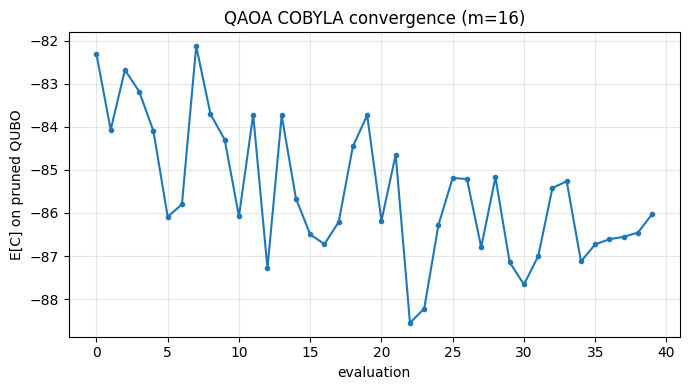

,nodes,horizon,qubits,method,qubo_energy,qubo_energy_pruned,closed_loop_cost,gap_to_optimum_%,kept_coupling_%,runtime_sec,backend,job_id,shots,depth
0,4,4,16,VQAOA_local_p2,-135.4747,-135.7456,46.6550,1.875,99.87,0.716,AerSimulator,,2048,59
1,6,4,24,VQAOA_local_p2,-177.5462,-183.4885,56.0784,NaN,96.69,67.259,AerSimulator,,2048,79


In [8]:
# ============================================================
# CELL 8 - Local Variational QAOA (COBYLA) on small instances
# ============================================================
def optimize_qaoa_local(inst, p=1, max_edges=100, opt_shots=512, maxiter=40,
                        final_shots=2048, seed=42, method="COBYLA"):
    if not HAS_QISKIT: raise RuntimeError("Qiskit unavailable.")
    Hq, gq = inst["Hq"], inst["gq"]; m = inst["m"]
    h, edges, kept = qubo_to_ising_terms(Hq, gq, max_edges=max_edges)
    Hp, gp = build_pruned_qubo(Hq, gq, edges)
    qc, params = build_param_qaoa(h, edges, m, p)
    sim = AerSimulator(seed_simulator=seed)
    tqc = transpile(qc, sim, optimization_level=1)

    def expectation(theta):
        counts = sim.run(tqc.assign_parameters(dict(zip(params, theta))), shots=opt_shots).result().get_counts()
        tot = sum(counts.values())
        return sum(c*qubo_value(bitstring_to_U(b), Hp, gp) for b, c in counts.items())/tot

    history = []
    rng = np.random.default_rng(seed)
    theta0 = np.concatenate([rng.uniform(0.2, 1.0, p), rng.uniform(0.2, 0.8, p)])
    t0 = time.time()
    out = minimize(lambda th: (lambda v: (history.append(v), v)[1])(expectation(th)),
                   theta0, method=method, options={"maxiter": maxiter})
    opt_time = time.time() - t0

    counts = sim.run(tqc.assign_parameters(dict(zip(params, out.x))), shots=final_shots).result().get_counts()
    U_full, e_full, bits = best_from_counts(counts, Hq, gq)     # graded on FULL qubo
    e_pruned = qubo_value(U_full, Hp, gp)                       # what the circuit targeted
    _, cl = simulate_policy_from_U(inst["A"], inst["B"], inst["F"], inst["Q"], inst["R"],
                                   inst["x0"], inst["w"], decode_U(U_full, inst["n"], inst["H"]))
    return {"U": U_full, "bits": bits, "angles": out.x, "history": history,
            "e_full": e_full, "e_pruned": e_pruned, "closed_loop": cl,
            "kept_fraction": kept, "depth": tqc.depth(), "opt_time": opt_time}

qaoa_local_rows = []
transfer_angles = None

small = build_instance(SMALL_INSTANCE["nodes"], SMALL_INSTANCE["horizon"], seed=SEED)
print(f"Optimizing QAOA on small instance m={small['m']} ...")
r = optimize_qaoa_local(small, p=QAOA_P, max_edges=MAX_QAOA_EDGES.get(small["m"], 100),
                        opt_shots=OPT_SHOTS, maxiter=OPT_MAXITER, final_shots=SHOTS,
                        seed=SEED, method=OPT_METHOD)
transfer_angles = r["angles"]
bf_U = solve_bruteforce_qubo(small["Hq"], small["gq"])
opt_e = qubo_value(bf_U, small["Hq"], small["gq"]) if bf_U is not None else best_known.get(small["m"], r["e_full"])
print(f"  best sample (full QUBO) = {r['e_full']:.3f} | exact optimum = {opt_e:.3f} | retained couplings = {r['kept_fraction']*100:.1f}%")
qaoa_local_rows.append({
    "nodes": small["n"], "horizon": small["H"], "qubits": small["m"],
    "method": f"VQAOA_local_p{QAOA_P}", "qubo_energy": round(r["e_full"], 4),
    "qubo_energy_pruned": round(r["e_pruned"], 4), "closed_loop_cost": round(r["closed_loop"], 4),
    "gap_to_optimum_%": round(100*(r["e_full"]-opt_e)/(abs(opt_e)+1e-9), 3),
    "kept_coupling_%": round(100*r["kept_fraction"], 2),
    "runtime_sec": round(r["opt_time"], 3), "backend": "AerSimulator",
    "job_id": "", "shots": SHOTS, "depth": r["depth"]})

if OPTIMIZE_MEDIUM:
    med = build_instance(MEDIUM_INSTANCE["nodes"], MEDIUM_INSTANCE["horizon"], seed=SEED)
    print(f"Optimizing QAOA on medium instance m={med['m']} ...")
    rm = optimize_qaoa_local(med, p=QAOA_P, max_edges=MAX_QAOA_EDGES.get(med["m"], 150),
                             opt_shots=OPT_SHOTS, maxiter=OPT_MAXITER, final_shots=SHOTS, seed=SEED, method=OPT_METHOD)
    qaoa_local_rows.append({
        "nodes": med["n"], "horizon": med["H"], "qubits": med["m"],
        "method": f"VQAOA_local_p{QAOA_P}", "qubo_energy": round(rm["e_full"], 4),
        "qubo_energy_pruned": round(rm["e_pruned"], 4), "closed_loop_cost": round(rm["closed_loop"], 4),
        "gap_to_optimum_%": np.nan, "kept_coupling_%": round(100*rm["kept_fraction"], 2),
        "runtime_sec": round(rm["opt_time"], 3), "backend": "AerSimulator",
        "job_id": "", "shots": SHOTS, "depth": rm["depth"]})

local_df = pd.DataFrame(qaoa_local_rows)

# Convergence plot for the small instance
plt.figure(figsize=(7, 4))
plt.plot(r["history"], marker="o", ms=3)
plt.title(f"QAOA COBYLA convergence (m={small['m']})")
plt.xlabel("evaluation"); plt.ylabel("E[C] on pruned QUBO"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
local_df

# Step 5 - Parameter Transfer to Large Instances

Optimizing QAOA angles directly on 64-152 qubit hardware circuits is impractical. We instead
**transfer** the angles optimized on the small simulable instance. QAOA parameter
transferability across problem sizes is an established phenomenon (Galda et al., 2021;
Akshay et al., 2021). This makes the large-scale runs a defensible **feasibility / scale**
demonstration rather than an untrained one-shot circuit.

In [9]:
# ============================================================
# CELL 9 - Transferred angles
# ============================================================
if transfer_angles is None:
    transfer_angles = np.array([0.6]*QAOA_P + [0.4]*QAOA_P)
gammas_T = list(transfer_angles[:QAOA_P]); betas_T = list(transfer_angles[QAOA_P:])
print("Transferred gammas:", np.round(gammas_T, 4))
print("Transferred betas :", np.round(betas_T, 4))

Transferred gammas: [2.3213 0.0938]
Transferred betas : [0.6923 1.3684]


In [10]:
# ============================================================
# CELL 10 - IBM Quantum Connection (gated by USE_IBM)
# ============================================================
service = None; backend = None
if USE_IBM:
    IBM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN")
    IBM_INSTANCE = os.getenv("IBM_QUANTUM_INSTANCE")
    if IBM_TOKEN is None:
        raise ValueError("Set IBM_QUANTUM_TOKEN env var. Do not paste tokens in the notebook.")
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
    if IBM_INSTANCE:
        service = QiskitRuntimeService(channel="ibm_cloud", token=IBM_TOKEN, instance=IBM_INSTANCE)
    else:
        service = QiskitRuntimeService(channel="ibm_quantum", token=IBM_TOKEN)
    backend = service.least_busy(simulator=False, operational=True, min_num_qubits=156)
    print("Backend:", backend.name, "| qubits:", backend.num_qubits)
else:
    print("USE_IBM=False. IBM cells will not run.")

qiskit_runtime_service._discover_account:WARNING:2026-06-07 17:23:41,085: Loading account with the given token. A saved account will not be used.


Backend: ibm_marrakesh | qubits: 156


In [11]:
# ============================================================
# CELL 11 - IBM QAOA runner (transferred angles, consistent scoring)
# ============================================================
def build_fixed_qaoa(Hq, gq, gammas, betas, max_edges):
    h, edges, kept = qubo_to_ising_terms(Hq, gq, max_edges=max_edges)
    Hp, gp = build_pruned_qubo(Hq, gq, edges)
    qc = QuantumCircuit(len(gq), len(gq)); qc.h(range(len(gq)))
    for l in range(len(gammas)):
        for i in range(len(gq)):
            if abs(h[i]) > 1e-12: qc.rz(2*gammas[l]*h[i], i)
        for i, j, Jij in edges: qc.rzz(2*gammas[l]*Jij, i, j)
        for i in range(len(gq)): qc.rx(2*betas[l], i)
    qc.measure(range(len(gq)), range(len(gq)))
    return qc, Hp, gp, kept

def run_ibm_qaoa(inst, gammas, betas, shots=2048, max_edges=500):
    if not USE_IBM: raise RuntimeError("Set USE_IBM=True first.")
    from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler
    Hq, gq = inst["Hq"], inst["gq"]
    qc, Hp, gp, kept = build_fixed_qaoa(Hq, gq, gammas, betas, max_edges)
    print("Logical qubits:", qc.num_qubits, "| logical depth:", qc.depth(), "| retained couplings:", f"{kept*100:.1f}%")
    t0 = time.time(); tqc = transpile(qc, backend=backend, optimization_level=1); ttime = time.time()-t0
    print("Transpiled depth:", tqc.depth(), "| transpile time:", round(ttime, 2))
    ops = tqc.count_ops()
    cx_count = (
        ops.get("cx",0)
        + ops.get("ecr",0)
    )
    print("Transpiled depth:", tqc.depth())
    print("2Q gates:", cx_count)
    sampler = RuntimeSampler(mode=backend)
    job = sampler.run([tqc], shots=shots); print("IBM Job ID:", job.job_id())
    t0 = time.time(); result = job.result(); wall = time.time()-t0
    data = result[0].data; reg = list(data.keys())[0]; counts = data[reg].get_counts()
    U, e_full, bits = best_from_counts(counts, Hq, gq)
    e_pruned = qubo_value(U, Hp, gp)
    _, cl = simulate_policy_from_U(inst["A"], inst["B"], inst["F"], inst["Q"], inst["R"],
                                   inst["x0"], inst["w"], decode_U(U, inst["n"], inst["H"]))
    return {"e_full": e_full, "e_pruned": e_pruned, "closed_loop": cl, "kept": kept,
            "backend": backend.name, "job_id": job.job_id(), "shots": shots,
            "depth": tqc.depth(), "wall": wall,"cx_count": cx_count,"logical_qubits": qc.num_qubits,"physical_qubits": tqc.num_qubits,}

print("IBM QAOA runner ready (transferred angles, dual scoring).")

IBM QAOA runner ready (transferred angles, dual scoring).


In [12]:
# ============================================================
# CELL 12 - Run IBM Experiments (gated)  [feasibility / scale demo]
# ============================================================
RUN_IBM_64, RUN_IBM_128, RUN_IBM_152 = True, True, True
ibm_rows = []

def execute_ibm(inst):
    m = inst["m"]; me = MAX_QAOA_EDGES.get(m, 500)
    print("="*70); print(f"IBM QAOA  n={inst['n']} H={inst['H']} qubits={m}"); print("="*70)
    res = run_ibm_qaoa(inst, gammas_T, betas_T, shots=SHOTS, max_edges=me)
    bk = best_known.get(m, res["e_full"])
    return {"nodes": inst["n"], "horizon": inst["H"], "qubits": m,
            "method": f"IBM_QAOA_p{QAOA_P}_transfer", "qubo_energy": round(res["e_full"], 4),
            "qubo_energy_pruned": round(res["e_pruned"], 4), "closed_loop_cost": round(res["closed_loop"], 4),
            "gap_to_best_%": round(100*(res["e_full"]-bk)/(abs(bk)+1e-9), 3),
            "kept_coupling_%": round(100*res["kept"], 2), "runtime_sec": round(res["wall"], 3),
            "backend": res["backend"], "job_id": res["job_id"], "shots": res["shots"], "depth": res["depth"],"cx_count": res["cx_count"],
"logical_qubits": res["logical_qubits"],
"physical_qubits": res["physical_qubits"],}

if USE_IBM and RUN_IBM_64:  ibm_rows.append(execute_ibm(instances[0]))
if USE_IBM and RUN_IBM_128: ibm_rows.append(execute_ibm(instances[1]))
if USE_IBM and RUN_IBM_152: ibm_rows.append(execute_ibm(instances[2]))

ibm_df = pd.DataFrame(ibm_rows)
ibm_df if len(ibm_rows) else "No IBM runs (USE_IBM / RUN_IBM_* are False)."

IBM QAOA  n=8 H=8 qubits=64
Logical qubits: 64 | logical depth: 130 | retained couplings: 60.1%
Transpiled depth: 4095 | transpile time: 0.07
Transpiled depth: 4095
2Q gates: 0
IBM Job ID: d8ipm666983c73dsegsg
IBM QAOA  n=16 H=8 qubits=128
Logical qubits: 128 | logical depth: 147 | retained couplings: 43.5%
Transpiled depth: 6066 | transpile time: 0.11
Transpiled depth: 6066
2Q gates: 0
IBM Job ID: d8ipmee6983c73dseh60
IBM QAOA  n=19 H=8 qubits=152
Logical qubits: 152 | logical depth: 153 | retained couplings: 46.4%
Transpiled depth: 8019 | transpile time: 0.17
Transpiled depth: 8019
2Q gates: 0
IBM Job ID: d8ipmglv8cos73f5t9l0


,nodes,horizon,qubits,method,qubo_energy,qubo_energy_pruned,closed_loop_cost,gap_to_best_%,kept_coupling_%,runtime_sec,backend,job_id,shots,depth,cx_count,logical_qubits,physical_qubits
0,8,8,64,IBM_QAOA_p2_transfer,-3462.4320,-4381.4718,339.1575,3.915,60.09,30.212,ibm_marrakesh,d8ipm666983c73dsegsg,2048,4095,0,64,156
1,16,8,128,IBM_QAOA_p2_transfer,-6463.0040,-10952.4215,551.5539,7.689,43.45,7.796,ibm_marrakesh,d8ipmee6983c73dseh60,2048,6066,0,128,156
2,19,8,152,IBM_QAOA_p2_transfer,-7434.7824,-13619.0475,695.5127,9.120,46.43,8.165,ibm_marrakesh,d8ipmglv8cos73f5t9l0,2048,8019,0,152,156


In [13]:
# ============================================================
# CELL 13 - Combined Results Table
# ============================================================
frames = [baseline_df]
if len(qaoa_local_rows): frames.append(pd.DataFrame(qaoa_local_rows))
if len(ibm_rows):        frames.append(pd.DataFrame(ibm_rows))
results_df = pd.concat(frames, ignore_index=True, sort=False)
results_df.rename(
    columns={
        "gap_to_best_%":"gap_to_best_found_%"
    },
    inplace=True
)
results_df = results_df.sort_values(["qubits", "qubo_energy"], ascending=[True, True]).reset_index(drop=True)
results_df.to_csv("unified_control_qubo_qaoa_results.csv", index=False)
results_df

,nodes,horizon,qubits,method,qubo_energy,closed_loop_cost,gap_to_best_found_%,proven_optimal,runtime_sec,backend,job_id,shots,depth,qubo_energy_pruned,gap_to_optimum_%,kept_coupling_%,cx_count,logical_qubits,physical_qubits
0,4,4,16,VQAOA_local_p2,-135.4747,46.6550,NaN,NaN,0.7160,AerSimulator,,2048,59,-135.7456,1.875,99.87,NaN,NaN,NaN
1,6,4,24,VQAOA_local_p2,-177.5462,56.0784,NaN,NaN,67.2590,AerSimulator,,2048,79,-183.4885,NaN,96.69,NaN,NaN,NaN
2,8,8,64,CP-SAT,-3603.5012,290.3671,0.000,False,20.0526,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,8,8,64,SimulatedAnnealing,-3594.4082,296.5242,0.252,False,272.5173,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,8,8,64,IBM_QAOA_p2_transfer,-3462.4320,339.1575,3.915,NaN,30.2120,ibm_marrakesh,d8ipm666983c73dsegsg,2048,4095,-4381.4718,NaN,60.09,0.0,64.0,156.0
5,8,8,64,Greedy,8557.4376,89.3025,337.476,False,0.0000,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,16,8,128,CP-SAT,-7001.3569,535.9052,0.000,False,20.1214,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,16,8,128,SimulatedAnnealing,-6962.3764,562.1299,0.557,False,1044.3008,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,16,8,128,IBM_QAOA_p2_transfer,-6463.0040,551.5539,7.689,NaN,7.7960,ibm_marrakesh,d8ipmee6983c73dseh60,2048,6066,-10952.4215,NaN,43.45,0.0,128.0,156.0
9,16,8,128,Greedy,17791.2885,143.5475,354.112,False,0.0000,classical,,0,0,NaN,NaN,NaN,NaN,NaN,NaN


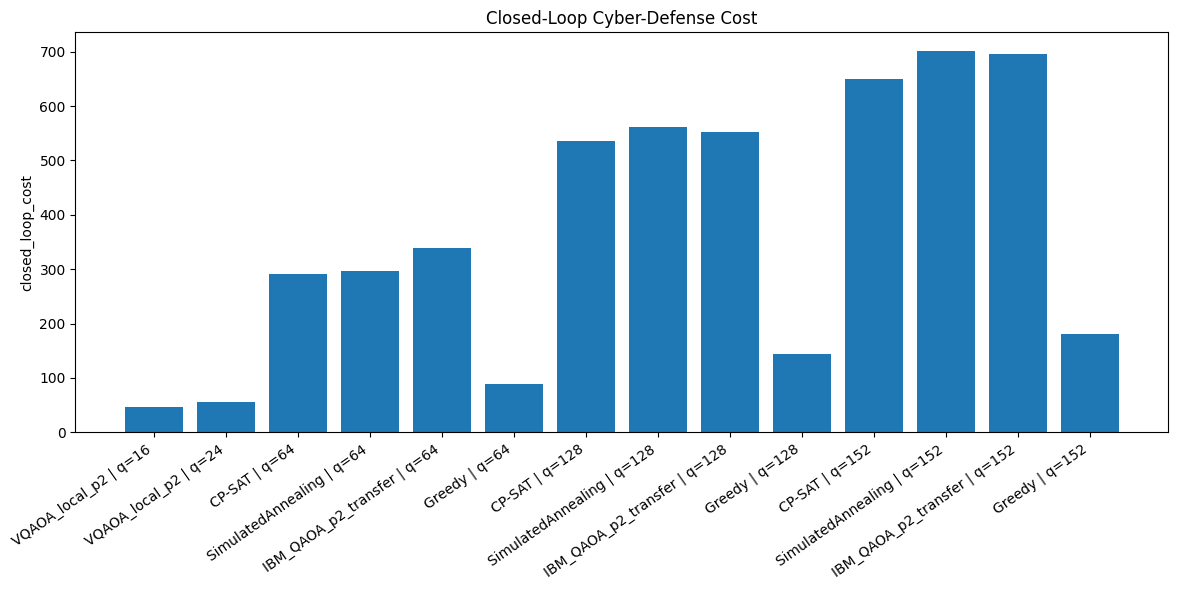

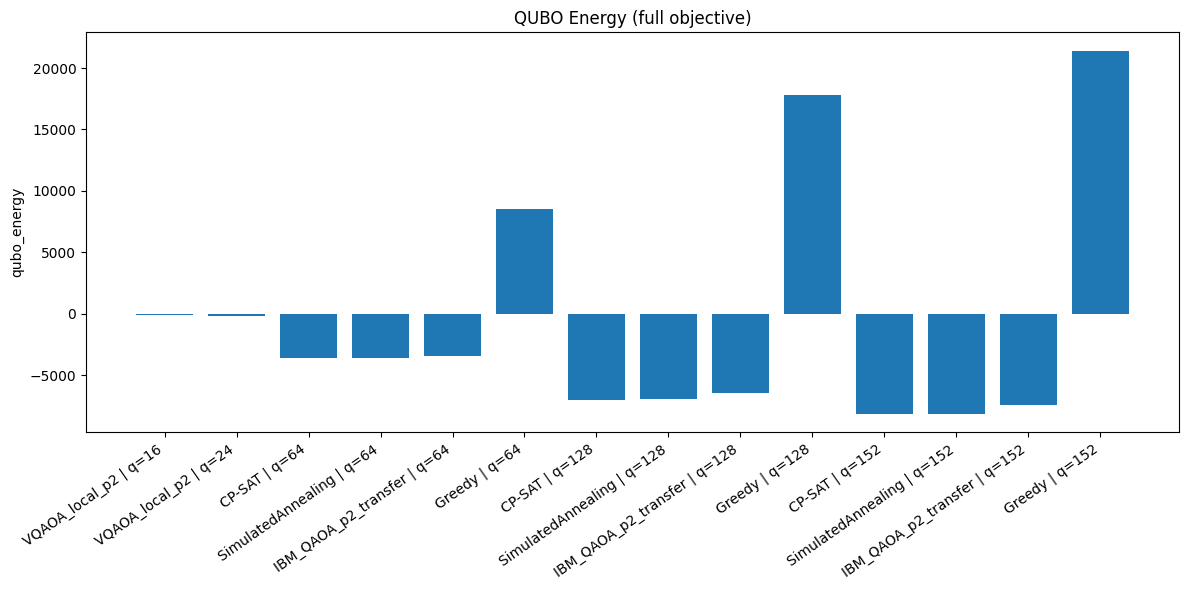

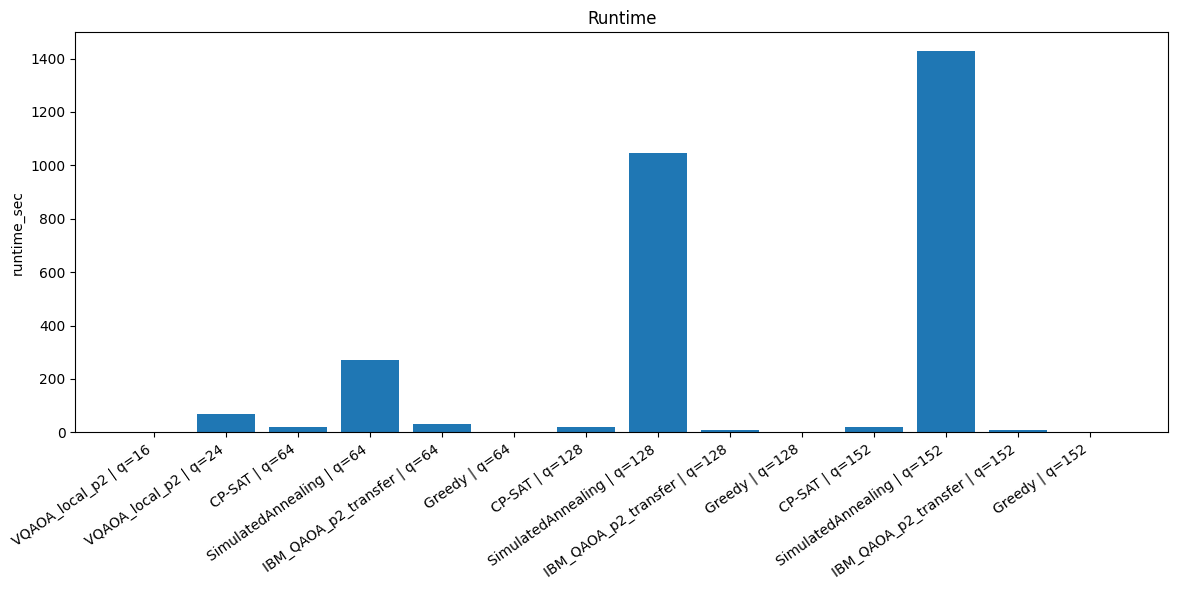

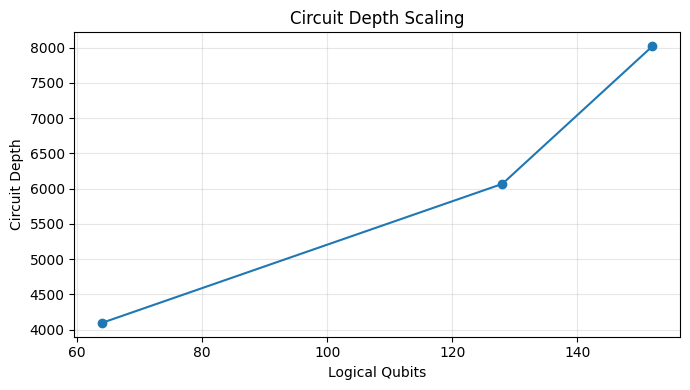

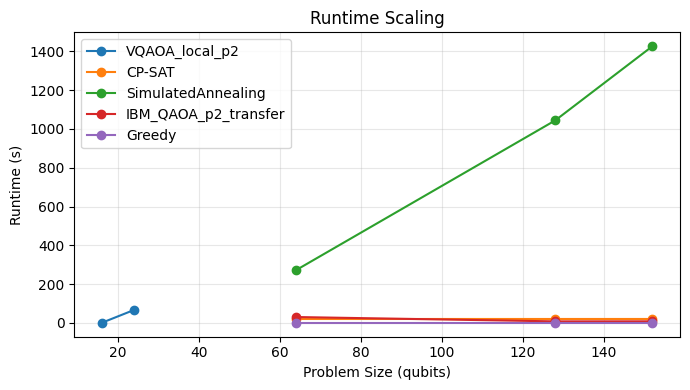

In [17]:
# ============================================================
# CELL 14 - Figures
# ============================================================
df = results_df.copy()
labels = df["method"] + " | q=" + df["qubits"].astype(str)

for col, title, fname in [
    ("closed_loop_cost", "Closed-Loop Cyber-Defense Cost", "fig_closed_loop_cost.png"),
    ("qubo_energy",      "QUBO Energy (full objective)",    "fig_qubo_energy.png"),
    ("runtime_sec",      "Runtime",                          "fig_runtime.png")]:
    if col not in df: continue
    plt.figure(figsize=(12, 6))
    plt.bar(labels, df[col]); plt.title(title); plt.ylabel(col)
    plt.xticks(rotation=35, ha="right"); plt.tight_layout()
    plt.savefig(fname, dpi=300); plt.show()
if "depth" in results_df.columns:

    qdf = results_df[
        results_df["method"].str.contains("IBM_QAOA", na=False)
    ]

    if len(qdf):

        plt.figure(figsize=(7,4))

        plt.plot(
            qdf["qubits"],
            qdf["depth"],
            marker="o"
        )

        plt.xlabel("Logical Qubits")
        plt.ylabel("Circuit Depth")
        plt.title("Circuit Depth Scaling")
        plt.grid(alpha=.3)

        plt.tight_layout()
        plt.show()
plt.figure(figsize=(7,4))

for m in results_df["method"].unique():

    sdf = results_df[
        results_df["method"] == m
    ]

    plt.plot(
        sdf["qubits"],
        sdf["runtime_sec"],
        marker="o",
        label=m
    )

plt.xlabel("Problem Size (qubits)")
plt.ylabel("Runtime (s)")
plt.title("Runtime Scaling")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

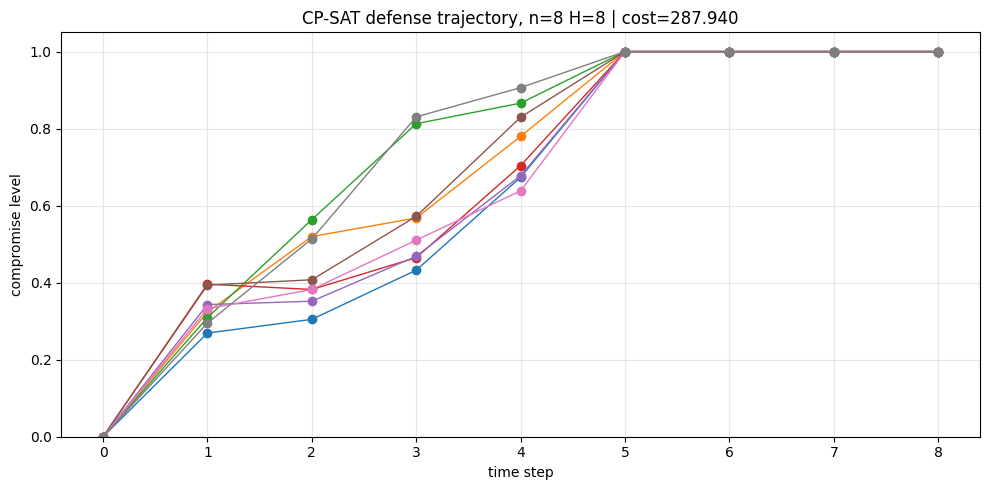

In [18]:
# ============================================================
# CELL 15 - Compromise Trajectory under CP-SAT policy
# ============================================================
def plot_trajectory(inst, U, title):
    Um = decode_U(U, inst["n"], inst["H"])
    x, cost = simulate_policy_from_U(inst["A"], inst["B"], inst["F"], inst["Q"], inst["R"],
                                     inst["x0"], inst["w"], Um)
    s = x[0:inst["n"], :]
    plt.figure(figsize=(10, 5))
    for i in range(inst["n"]): plt.plot(range(inst["H"]+1), s[i, :], marker="o", lw=1)
    plt.title(f"{title} | cost={cost:.3f}"); plt.xlabel("time step"); plt.ylabel("compromise level")
    plt.ylim(0, 1.05); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

inst8 = instances[0]
res8 = solve_cpsat_qubo(inst8["Hq"], inst8["gq"], time_limit=20)
U8 = res8[0] if isinstance(res8, tuple) else res8
plot_trajectory(inst8, U8, "CP-SAT defense trajectory, n=8 H=8")

# Methodology Wording (paper)

> The framework begins with a discrete-time networked state-space optimal-control model of cyber
> defense whose state captures compromise level, attacker knowledge, vulnerability exposure and
> asset criticality, with binary defense actions as the control input. Over a finite prediction
> horizon the binary optimal-control problem is reduced **exactly** to a Quadratic Unconstrained
> Binary Optimization problem; we verify numerically that the QUBO energy equals the unclipped
> closed-loop cost up to an additive constant. The same QUBO is solved by classical baselines
> (CP-SAT, simulated annealing, with brute force providing the exact optimum on small instances)
> and by the Quantum Approximate Optimization Algorithm whose variational angles are **optimized
> with COBYLA** on a statevector simulator. To keep hardware depth tractable, the QAOA cost layer
> retains the strongest QUBO couplings; we report energies on both the retained and full
> objectives together with the retained coupling-weight fraction. For 64-152 qubit instances, the
> optimized angles are **transferred** to IBM hardware, yielding a reproducible feasibility and
> scale demonstration evaluated against a strong classical optimizer.

> **Scope statement.** The large-scale IBM runs are presented as a feasibility/scale demonstration
> at p=1 with transferred angles; they are not claimed to outperform the classical baselines.

In [19]:
# ============================================================
# CELL 16 - LaTeX Table Export
# ============================================================
cols = [
    c for c in [
        "nodes",
        "horizon",
        "qubits",
        "method",
        "qubo_energy",
        "closed_loop_cost",
        "gap_to_best_found_%",
        "kept_coupling_%",
        "runtime_sec",
        "depth",
        "cx_count",
        "backend",
        "shots"
    ]
    if c in results_df.columns
]

print(results_df[cols].to_latex(index=False))

\begin{tabular}{rrrlrrrrrrrlr}
\toprule
nodes & horizon & qubits & method & qubo_energy & closed_loop_cost & gap_to_best_found_% & kept_coupling_% & runtime_sec & depth & cx_count & backend & shots \\
\midrule
4 & 4 & 16 & VQAOA_local_p2 & -135.474700 & 46.655000 & NaN & 99.870000 & 0.716000 & 59 & NaN & AerSimulator & 2048 \\
6 & 4 & 24 & VQAOA_local_p2 & -177.546200 & 56.078400 & NaN & 96.690000 & 67.259000 & 79 & NaN & AerSimulator & 2048 \\
8 & 8 & 64 & CP-SAT & -3603.501200 & 290.367100 & 0.000000 & NaN & 20.052600 & 0 & NaN & classical & 0 \\
8 & 8 & 64 & SimulatedAnnealing & -3594.408200 & 296.524200 & 0.252000 & NaN & 272.517300 & 0 & NaN & classical & 0 \\
8 & 8 & 64 & IBM_QAOA_p2_transfer & -3462.432000 & 339.157500 & 3.915000 & 60.090000 & 30.212000 & 4095 & 0.000000 & ibm_marrakesh & 2048 \\
8 & 8 & 64 & Greedy & 8557.437600 & 89.302500 & 337.476000 & NaN & 0.000000 & 0 & NaN & classical & 0 \\
16 & 8 & 128 & CP-SAT & -7001.356900 & 535.905200 & 0.000000 & NaN & 20.121400 &